# README

This Google Colab Notebook is separated into 3 parts:
- PDF Setup
- Model Inference
- Visualize Results

Each section is labeled with a numbered box. The purpose of each section is described here. It is assumed that you have downloaded [this drive](https://drive.google.com/drive/u/1/folders/1Y9xMZY1rZL_MC1shTnPAfEPkh80S83UL) and have placed it in the "My Drive" section in your Google account.

---

**PDF Setup:**

The purpose of this section is to grab pdf files from `pdfs/` and process them into images for `pages_300dpi/`. You should already have all the processed images in the `pages_300dpi/` directory as well as the `ground_truth_coordinates.json` file. Place that JSON file into the files used in this project, and you should be ready for Part 2.

If for some reason, you seek to add more images and evaluate them on your own, it will be your responsibility to make sure that your version of the ``ground_truth_coordinates.json`` reflects the pdfs that you are processing.

---

**Model Inference:**

This is where everything happens. As soon as you run the first 2 cells, feel free to pick any model to run. Once you run the model (and possibly experiment with different queries and thresholds), you should have access to various csv files showing the results in the `results/` folder.

In here are 3 subfolders:
- `detailed/`
- `prompt_precision/`
- `summary/`

It should be no issue to add new subsections that run your own model.

---

**Visualize Results:**

The purpose of this section is to serve as a debugging step after you've run a model. You are provided with a set of images of the bounding boxes of successes and failures to get an idea of what to change in your next iteration.

---

# [1] PDF SETUP

## Installation

In [ ]:
# --- INSTALLATION ---
!apt-get update -qq
!apt-get install -y poppler-utils
!pip install -q pdf2image pillow pandas torch torchvision transformers tqdm label-studio-sdk

import os
import json
import subprocess
import pandas as pd
from pathlib import Path
from PIL import Image

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 98 not upgraded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- CONFIGURATION ---
BASE_DIR = Path("/content/drive/MyDrive/warrant_experiments")
PDF_DIR = BASE_DIR / "pdfs"
IMG_DIR = BASE_DIR / "pages_300dpi"
IMG_DIR.mkdir(parents=True, exist_ok=True)

print(PDF_DIR)

/content/drive/MyDrive/warrant_experiments/pdfs


## PDF Conversion and Handling

In [ ]:
# 1. Convert PDFs to Images
pdfs = list(PDF_DIR.glob("*.pdf"))
print(f"PDFs found: {len(pdfs)}")

for pdf in pdfs:
    out_prefix = IMG_DIR / pdf.stem
    # Only convert if not already done (saves time on re-runs)
    if not list(IMG_DIR.glob(f"{pdf.stem}*.png")):
        subprocess.run(
            ["pdftoppm", "-png", "-r", "300", str(pdf), str(out_prefix)],
            check=True
        )

# 2. Load Only First Pages
# We use "*-1.png" to catch "doc-1.png" but strictly exclude "doc-11.png"
images = sorted(list(IMG_DIR.glob("*-1.png")))

# Safety Limit (Optional)
N = 250
images = images[:N]

print(f"Selected {len(images)} first-page images for processing.")

# Create indexing dataframe
df_pages = pd.DataFrame([
    {"doc_id": p.stem.replace("-1", ""), "page_index": 1, "image_path": str(p)}
    for p in images
])
display(df_pages.head())

PDFs found: 200
Selected 199 first-page images for processing.


,doc_id,page_index,image_path
0,1-21-mc-00071-AJ,1,/content/drive/MyDrive/warrant_experiments/pag...
1,1-21-mc-00072-AJ,1,/content/drive/MyDrive/warrant_experiments/pag...
2,1-21-mc-00073-AJ,1,/content/drive/MyDrive/warrant_experiments/pag...
3,1-21-mc-00074-AJ,1,/content/drive/MyDrive/warrant_experiments/pag...
4,1-21-mc-00075-AJ,1,/content/drive/MyDrive/warrant_experiments/pag...


Create a zip file for Label Studio to get the coordinates of bounding boxes for your images. Label those properly and add the label json file `ground_truth.json`, into your main folder. For us, that is `/content/drive/MyDrive/warrant_experiments/`.

NOTE: `ground_truth.json` may already be downloaded, skip this step if it's already there. (If you didn't change any images, you should have skipped this entire section already.)

In [ ]:
import shutil

# --- CONFIGURATION ---
ZIP_PATH = BASE_DIR / "images_to_label2.zip"

# 1. Select Only First Pages
# Pattern "*-1.png" captures "doc-1.png" but strictly excludes "doc-11.png"
first_pages = sorted(list(IMG_DIR.glob("*-1.png")))

print(f"Selected {len(first_pages)} first-page images for labeling.")

# 2. Create Zip File
# -j: junk paths (flatten folders so images are at the root of the zip)
cmd = f"zip -j '{ZIP_PATH}' " + " ".join([f"'{str(p)}'" for p in first_pages])

# Execute zip command
os.system(cmd)

print(f"✅ Zip created at: {ZIP_PATH}")
print("⬇️ ACTION REQUIRED: Go to your Google Drive, download this zip, and import it into Label Studio.")

Selected 199 first-page images for labeling.
✅ Zip created at: /content/drive/MyDrive/warrant_experiments/images_to_label2.zip
⬇️ ACTION REQUIRED: Go to your Google Drive, download this zip, and import it into Label Studio.


# [2] MODEL INFERENCE

## Setup

In [ ]:
# --- INSTALLATION ---
!pip install -q transformers torch pandas pillow tqdm

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import pandas as pd
from pathlib import Path
from PIL import Image

# --- CONFIGURATION ---
BASE_DIR = Path("/content/drive/MyDrive/warrant_experiments")
IMG_DIR = BASE_DIR / "pages_300dpi"
# Update this to the actual name of the file you uploaded
GT_PATH = BASE_DIR / "ground_truth_coordinates.json"

# 1. Load Images
image_files = sorted(list(IMG_DIR.glob("*-1.png")))

if not image_files:
    print("⚠️ No images found! Did you run Phase 1?")
else:
    df_pages = pd.DataFrame([
        {
            "doc_id": p.stem.replace("-1", ""),
            "image_path": str(p),
            "filename": p.name
        }
        for p in image_files
    ])
    print(f"✅ Loaded {len(df_pages)} images for evaluation.")

# 2. Load Ground Truth (FIXED)
gt_map = {}
if GT_PATH.exists():
    with open(GT_PATH, 'r') as f:
        data = json.load(f)

    for entry in data:
        full_path = entry.get('image') or entry.get('data', {}).get('image', '')
        ls_filename = os.path.basename(full_path)

        # --- THE FIX: REMOVE LABEL STUDIO UUID PREFIX ---
        # Label Studio makes files look like "8273ac-doc1.png"
        # We split by the first '-' and take the second part to get "doc1.png"
        if '-' in ls_filename:
            # This handles the standard LS format: "uuid-filename.png"
            clean_filename = ls_filename.split('-', 1)[1]
        else:
            clean_filename = ls_filename
        # ------------------------------------------------

        if 'label' in entry and entry['label']:
            lbl = entry['label'][0]
            w_orig = lbl.get('original_width')
            h_orig = lbl.get('original_height')

            if w_orig and h_orig:
                gt_map[clean_filename] = [
                    (lbl['x'] / 100) * w_orig,
                    (lbl['y'] / 100) * h_orig,
                    (lbl['x'] / 100) * w_orig + (lbl['width'] / 100) * w_orig,
                    (lbl['y'] / 100) * h_orig + (lbl['height'] / 100) * h_orig
                ]
    print(f"✅ Loaded Ground Truth for {len(gt_map)} images.")
    # Debug print to see if keys match now
    if len(gt_map) > 0:
        print(f"   Sample Key: {list(gt_map.keys())[0]}")
else:
    print(f"❌ WARNING: Could not find {GT_PATH}. IoU cannot be calculated.")

ValueError: mount failed

### General Evaluation and Reporting Function

In [ ]:
# --- PREDICTION AND REPORTING FUNCTION ---
import pandas as pd
import numpy as np

# We wrap your code in this function definition:
def evaluate_and_export(df_predictions, gt_map, experiment_name, base_dir, df_pages):
    """
    df_predictions: The dataframe coming from the model (Cell 3/4/5)
    gt_map: The loaded ground truth from Cell 1
    experiment_name: A string name for the CSV (e.g., "OwlViT_Large")
    """

    if df_predictions.empty:
        print(f"⚠️ {experiment_name}: No detections to evaluate.")
        # Create an empty DF for consistency if needed, or just return
        return

    # --- IOU HELPER (Your Code) ---
    def calculate_iou(boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
        unionArea = boxAArea + boxBArea - interArea
        return interArea / unionArea if unionArea > 0 else 0.0

    # --- BUILD DETAILED REPORT (Your Logic) ---
    final_rows = []

    # We use df_pages (passed as argument) to ensure we check every single file
    for _, row in df_pages.iterrows():
        filename = row["filename"]
        doc_id = row["doc_id"]

        # 1. Setup Base State
        has_gt = False
        detected = False
        iou = 0.0
        model_score = 0.0
        iou_threshold = 0.5
        winning_prompt = "N/A" # Added back for utility

        # Check Ground Truth
        gt_box = gt_map.get(filename)
        if gt_box:
            has_gt = True

        # Check Prediction (Top-1)
        # We look at 'df_predictions' instead of 'df_dets'
        if not df_predictions.empty:
            img_dets = df_predictions[df_predictions["filename"] == filename]
            if not img_dets.empty:
                detected = True
                best = img_dets.sort_values("score", ascending=False).iloc[0]
                model_score = best["score"]
                pred_box = best["bbox"]
                winning_prompt = best.get("query", "N/A") # Capture prompt if available

                if has_gt:
                    iou = calculate_iou(gt_box, pred_box)

        # 2. Determine Classification (TP/FP/TN/FN)
        is_tp = 0
        is_fp = 0
        is_tn = 0
        is_fn = 0
        status = ""

        if has_gt and detected:
            if iou >= iou_threshold:
                is_tp = 1
                status = "TP (Correct)"
            else:
                # Detected, but wrong place -> False Positive (Bad Box)
                # (Some count this as FN too, but let's stick to FP for bad loc)
                is_fp = 1
                status = "FP (Poor Loc)"

        elif has_gt and not detected:
            is_fn = 1
            status = "FN (Missed)"

        elif not has_gt and detected:
            is_fp = 1
            status = "FP (Hallucination)"

        elif not has_gt and not detected:
            is_tn = 1
            status = "TN (Correct Silence)"

        # 3. Save Entry
        final_rows.append({
            "doc_id": doc_id,
            "filename": filename,
            "has_ground_truth": has_gt,
            "detected": detected,
            "iou_score": iou,
            "model_score": model_score,
            "winning_prompt": winning_prompt,
            "status": status,
            "TP": is_tp,
            "FP": is_fp,
            "TN": is_tn,
            "FN": is_fn,
            "pred_box": str(pred_box) if detected else ""
        })

    # --- EXPORT DETAILED CSV ---
    df_eval = pd.DataFrame(final_rows)
    detailed_csv_name = f"{experiment_name}_results.csv"
    detailed_path = base_dir / 'results/detailed' / detailed_csv_name
    detailed_path.parent.mkdir(parents=True, exist_ok=True)
    df_eval.to_csv(detailed_path, index=False)
    print(f"📊 {experiment_name}: Detailed Matrix Saved")


    # --- EXPORT QUERY PERFORMANCE ---
    if not df_eval.empty:
        # Filter for rows where a prompt actually "won" (detected something)
        df_hits = df_eval[df_eval['detected'] == True]

        if not df_hits.empty:
            query_stats = df_hits.groupby('winning_prompt').agg(
                Count=('winning_prompt', 'count'),
                TP=('TP', 'sum'),
                FP=('FP', 'sum')
            ).reset_index()

            # Calculate Precision per prompt
            query_stats['Precision'] = query_stats['TP'] / (query_stats['TP'] + query_stats['FP'])

            query_path = base_dir / 'results/prompt_precision' / f"{experiment_name}_query_stats.csv"
            query_path.parent.mkdir(parents=True, exist_ok=True)
            query_stats.to_csv(query_path, index=False)
            print(f"Saved Query Stats: {query_path}")


    # --- CALCULATE & EXPORT SUMMARY CSV ---
    if not df_eval.empty:
        tp = df_eval["TP"].sum()
        fp = df_eval["FP"].sum()
        tn = df_eval["TN"].sum()
        fn = df_eval["FN"].sum()

        # Metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        accuracy = (tp + tn) / len(df_eval)

        # Create Summary DataFrame
        summary_data = [{
            "experiment_id": experiment_name,
            "total_images": len(df_eval),
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1_Score": round(f1, 4),
            "Accuracy": round(accuracy, 4)
        }]

        df_summary = pd.DataFrame(summary_data)

        # Export Summary
        summary_csv_name = f"{experiment_name}_summary_metrics.csv"
        summary_path = base_dir / 'results/summary' / summary_csv_name
        summary_path.parent.mkdir(parents=True, exist_ok=True)
        df_summary.to_csv(summary_path, index=False)

        print(f"✅ {experiment_name}: Summary Report Saved")
        print(f"   Prec: {precision:.2%} | Rec: {recall:.2%} | F1: {f1:.4f}")
    else:
        print("No data available to summarize.")

## OWL-ViT Standard

Importing

In [ ]:
import torch
from PIL import Image
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from tqdm import tqdm
from pathlib import Path

Model Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32").to(device)
model.eval()

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


OwlViTForObjectDetection(
  (owlvit): OwlViTModel(
    (text_model): OwlViTTextTransformer(
      (embeddings): OwlViTTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(16, 512)
      )
      (encoder): OwlViTEncoder(
        (layers): ModuleList(
          (0-11): 12 x OwlViTEncoderLayer(
            (self_attn): OwlViTAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): OwlViTMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_

Queries and Threshold

In [ ]:
EXP_NAME = "OwlViT_Base_Experiment"

CONF_THRESH = 0.05

TEXT_QUERIES = [
    "government seal",
    "court seal",
    "embossed seal",
    "official seal",
    "circular official seal",
    "circular government seal",
    "circular court seal",
    "circular embossed seal",
    "circular seal",
    "small seal",
    "small circular seal",
    "small government seal",
    "small court seal",
    "small embossed seal",
    "small official seal",
    "small circular official seal",
    "small circular government seal",
    "small circular court seal",
    "small circular embossed seal",
    "very small official seal",
    "very small government seal",
    "very small court seal",
    "very small embossed seal",
    "large official seal",
    "large government seal",
    "large court seal",
    "large embossed seal",
    "large circular official seal",
    "large circular government seal",
    "large circular court seal",
    "large circular embossed seal",
    "very large official seal",
    "very large government seal",
    "very large court seal",
    "very large embossed seal"
]

Inference Loop

In [ ]:
detections = []
print(f"Running {EXP_NAME} on {len(df_pages)} images...")

for _, row in tqdm(df_pages.iterrows(), total=len(df_pages)):
    img_path = row["image_path"]
    doc_id = row["doc_id"]

    try:
        image = Image.open(img_path).convert("RGB")
        inputs = processor(text=TEXT_QUERIES, images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]], device=device)
        results = processor.post_process_grounded_object_detection(
            outputs=outputs, target_sizes=target_sizes, threshold=CONF_THRESH
        )[0]

        boxes = results["boxes"].cpu().tolist()
        scores = results["scores"].cpu().tolist()

        for box, score in zip(boxes, scores):
            detections.append({
                "doc_id": doc_id,
                "image_path": img_path,
                "filename": Path(img_path).name, # Critical for matching GT
                "score": score,
                "bbox": box # [xmin, ymin, xmax, ymax]
            })

    except Exception as e:
        print(f"Error on {doc_id}: {e}")

df_dets = pd.DataFrame(detections)
print(f"Total detections: {len(df_dets)}")

Running OwlViT_Base_Experiment on 199 images...


100%|██████████| 199/199 [01:26<00:00,  2.31it/s]

Total detections: 121


Model Evaluation and Report

In [ ]:
evaluate_and_export(
    df_predictions=pd.DataFrame(detections),
    gt_map=gt_map,
    experiment_name=EXP_NAME,
    base_dir=BASE_DIR,
    df_pages=df_pages
)

📊 OwlViT_Base_Experiment: Detailed Matrix Saved
✅ OwlViT_Base_Experiment: Summary Report Saved
   Prec: 99.17% | Rec: 91.54% | F1: 0.9520


## OWL-ViT Large

Importing

In [ ]:
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import torch
from tqdm import tqdm
from PIL import Image
import pandas as pd

Model Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading OwlViT Large on {device}...")

# Note the model ID change: "large-patch14" instead of "base-patch32"
processor = OwlViTProcessor.from_pretrained("google/owlvit-large-patch14")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-large-patch14").to(device)
model.eval()

Loading OwlViT Large on cuda...


OwlViTForObjectDetection(
  (owlvit): OwlViTModel(
    (text_model): OwlViTTextTransformer(
      (embeddings): OwlViTTextEmbeddings(
        (token_embedding): Embedding(49408, 768)
        (position_embedding): Embedding(16, 768)
      )
      (encoder): OwlViTEncoder(
        (layers): ModuleList(
          (0-11): 12 x OwlViTEncoderLayer(
            (self_attn): OwlViTAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): OwlViTMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=768, out_features=3072, bias=True)
              (fc2): Linear(in_features=3072, out_

Queries and Threshold

In [ ]:
EXP_NAME = "OwlViT_Large_Experiment"

CONF_THRESH = 0.05

TEXT_QUERIES = [
    "official document seal",
    "embossed circular stamp",
    "faint government seal",
    "judicial court seal"
]

Model Inference

In [ ]:
detections = []
print(f"Running {EXP_NAME} on {len(df_pages)} images...")

for _, row in tqdm(df_pages.iterrows(), total=len(df_pages)):
    img_path = row["image_path"]
    doc_id = row["doc_id"]

    try:
        image = Image.open(img_path).convert("RGB")
        inputs = processor(text=TEXT_QUERIES, images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]], device=device)
        results = processor.post_process_grounded_object_detection(
            outputs=outputs, target_sizes=target_sizes, threshold=CONF_THRESH
        )[0]

        boxes = results["boxes"].cpu().tolist()
        scores = results["scores"].cpu().tolist()

        for box, score in zip(boxes, scores):
            detections.append({
                "doc_id": doc_id,
                "image_path": img_path,
                "filename": Path(img_path).name, # Critical for matching GT
                "score": score,
                "bbox": box # [xmin, ymin, xmax, ymax]
            })

    except Exception as e:
        print(f"Error on {doc_id}: {e}")

df_dets = pd.DataFrame(detections)
print(f"Total detections: {len(df_dets)}")

Running OwlViT_Large_Experiment on 199 images...


100%|██████████| 199/199 [05:37<00:00,  1.69s/it]

Total detections: 17155


Model Evaluation and Report


In [ ]:
evaluate_and_export(
    df_predictions=pd.DataFrame(detections),
    gt_map=gt_map,
    experiment_name=EXP_NAME,
    base_dir=BASE_DIR,
    df_pages=df_pages
)

📊 OwlViT_Large_Experiment: Detailed Matrix Saved
✅ OwlViT_Large_Experiment: Summary Report Saved
   Prec: 64.95% | Rec: 97.67% | F1: 0.7802


## Grounding DINO

Importing

In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch
from tqdm import tqdm
from PIL import Image
import pandas as pd

Queries and Threshold

In [ ]:
EXP_NAME = "GroundingDINO_Experiment"
BOX_THRESH = 0.20
TEXT_THRESH = 0.20

QUERIES = [
    "circular seal",
    "circular official seal"
    "official government stamp",
    "embossed paper seal",
    "official seal",
    "government seal",
    "court seal",
    "embossed seal"
]

Model Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Grounding DINO on {device}...")

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)

Model Inference

In [ ]:
detections = []
print(f"Running {EXP_NAME} on {len(df_pages)} images...")

for _, row in tqdm(df_pages.iterrows(), total=len(df_pages)):
    try:
        image = Image.open(row["image_path"]).convert("RGB")

        # DINO expects: "cat. dog. rat." (Dot separated string)
        text_prompt = ". ".join(QUERIES) + "."

        inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]], device=device)

        # --- Post-Processing Arguments ---
        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=BOX_THRESH,
            text_threshold=TEXT_THRESH,
            target_sizes=target_sizes
        )[0]

        for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
            detections.append({
                "filename": row["filename"],
                "query": label, # DINO returns the actual text string (e.g., "circular seal")
                "score": float(score),
                "bbox": box.tolist()
            })

    except Exception as e:
        print(f"Error on {row['filename']}: {e}")

Model Evaluation and Report


In [ ]:
evaluate_and_export(
    df_predictions=pd.DataFrame(detections),
    gt_map=gt_map,
    experiment_name=EXP_NAME,
    base_dir=BASE_DIR,
    df_pages=df_pages
)

## YOLO-WORLD

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLOWorld
import pandas as pd
from tqdm import tqdm
import torch

In [ ]:
EXP_NAME = "YOLO_World_Experiment"
CONF_THRESH = 0.01
QUERIES = [
    "government seal",
    "court seal",
    "official seal",
    "official ink stamp",
    "embossed seal",
    "embossed paper seal"
    "circular official seal",
    "circular government seal",
    "circular court seal",
    "circular embossed seal",
    "circular seal",
    "small seal",
    "small circular seal",
    "small government seal",
    "small court seal",
    "small embossed seal",
    "small official seal",
    "small circular official seal",
    "small circular government seal",
    "small circular court seal",
    "small circular embossed seal",
    "very small official seal",
    "very small government seal",
    "very small court seal",
    "very small embossed seal",
    "large official seal",
    "large government seal",
    "large court seal",
    "large embossed seal",
    "large circular official seal",
    "large circular government seal",
    "large circular court seal",
    "large circular embossed seal",
    "very large official seal",
    "very large government seal",
    "very large court seal",
    "very large embossed seal"
]


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading YOLO-World (Large) on {device}...")

model = YOLOWorld("yolov8l-worldv2.pt")
model.set_classes(QUERIES)

Loading YOLO-World (Large) on cuda...


In [ ]:
detections = []
print(f"Running {EXP_NAME} on {len(df_pages)} images...")

for _, row in tqdm(df_pages.iterrows(), total=len(df_pages)):
    try:
        # YOLO-World can read file paths directly
        # verbose=False keeps the log clean
        results = model.predict(row["image_path"], conf=CONF_THRESH, verbose=False, device=device)

        # Parse Results
        result = results[0] # We only sent one image

        for box, score, cls_id in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
            # Convert tensors to simple values
            box_list = box.cpu().tolist()
            score_val = float(score.cpu())
            label_name = result.names[int(cls_id)]

            detections.append({
                "filename": row["filename"],
                "doc_id": row["doc_id"],
                "query": label_name,
                "score": score_val,
                "bbox": box_list
            })

    except Exception as e:
        print(f"Error on {row['filename']}: {e}")

Running YOLO_World_Experiment on 199 images...


100%|██████████| 199/199 [01:01<00:00,  3.21it/s]


In [ ]:
evaluate_and_export(
    df_predictions=pd.DataFrame(detections),
    gt_map=gt_map,
    experiment_name=EXP_NAME,
    base_dir=BASE_DIR,
    df_pages=df_pages
)

📊 YOLO_World_Experiment: Detailed Matrix Saved
Saved Query Stats: /content/drive/MyDrive/warrant_experiments/results/prompt_precision/YOLO_World_Experiment_query_stats.csv
✅ YOLO_World_Experiment: Summary Report Saved
   Prec: 96.24% | Rec: 98.46% | F1: 0.9734


# [3] VISUALIZE RESULTS

Visualizing: YOLO_World_Experiment


/tmp/ipython-input-743088715.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


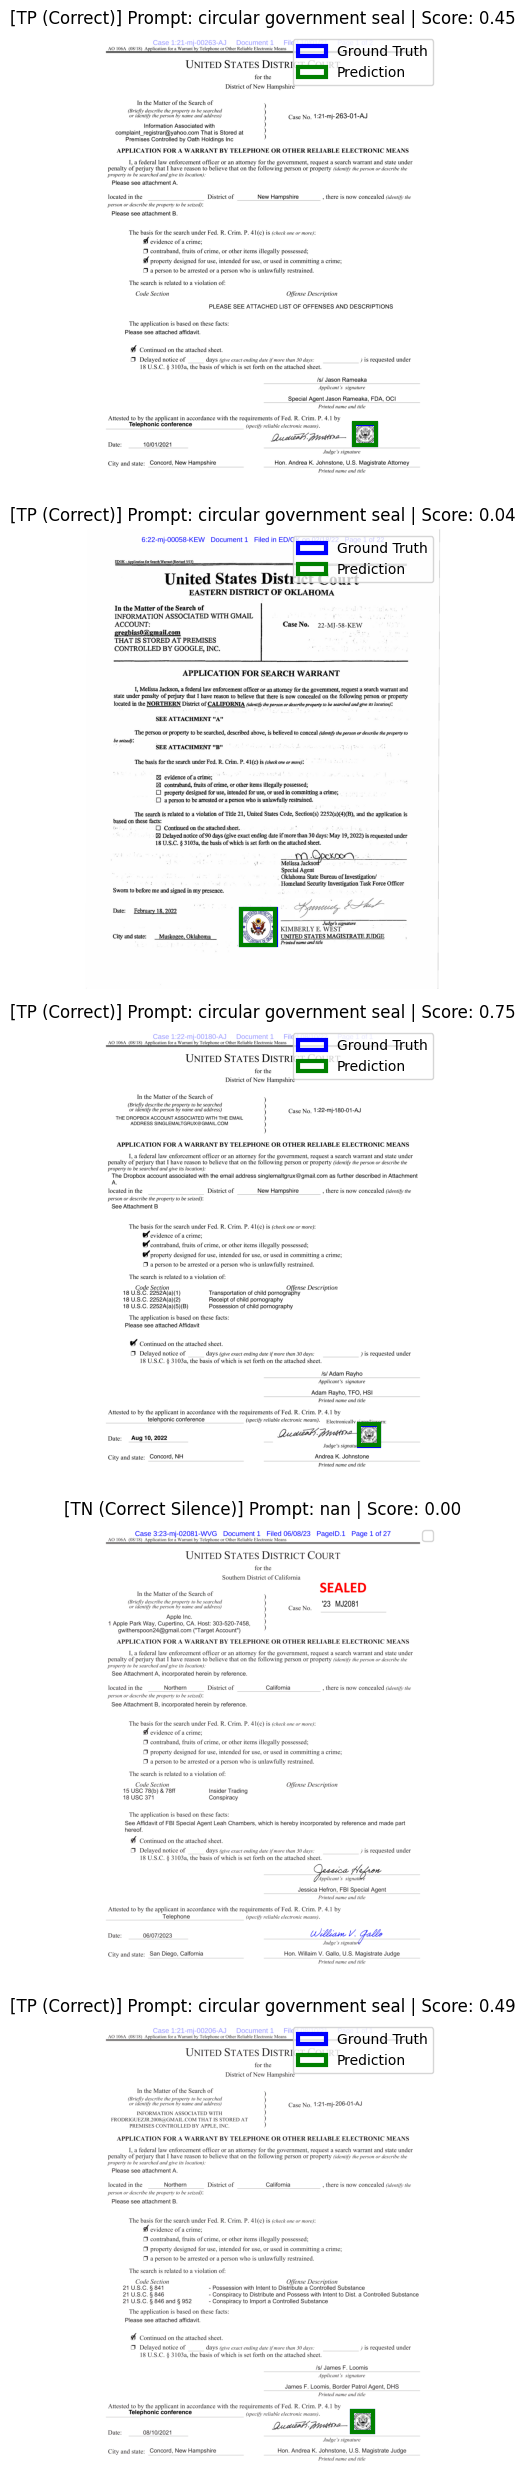

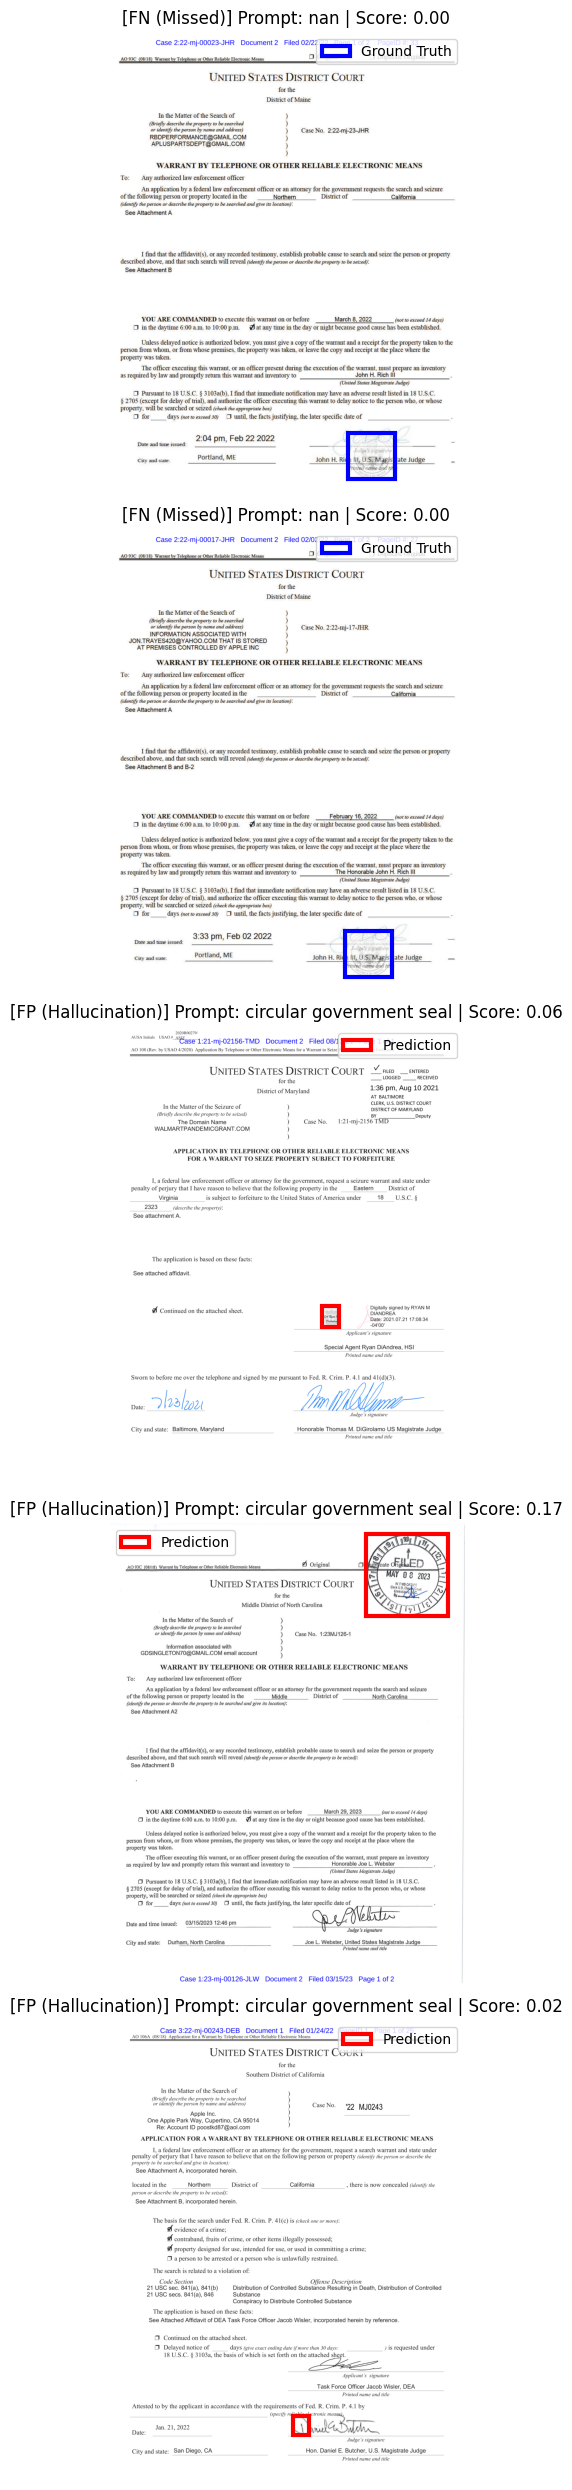

In [ ]:
# --- VISUALIZATION TOOL ---
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import ast

def visualize_results(df_detailed, base_dir, num_samples=5, show_errors_only=False):
    """
    Visualizes predictions.
    df_detailed: The dataframe loaded from 'results/detailed/...'
    show_errors_only: If True, only shows FP and FN cases.
    """

    # Filter based on mode
    if show_errors_only:
        subset = df_detailed[df_detailed['status'].isin(["FP (Hallucination)", "FP (Poor Loc)", "FN (Missed)"])]
        title_prefix = "ERROR CASES"
    else:
        subset = df_detailed
        title_prefix = "RANDOM SAMPLES"

    if subset.empty:
        print("No images found for this criteria.")
        return

    # Sample random rows
    n = min(num_samples, len(subset))
    samples = subset.sample(n)

    plt.figure(figsize=(15, 5 * n))

    for i, (_, row) in enumerate(samples.iterrows()):
        # Load Image
        # We need to reconstruct the full path.
        # Assuming your images are in 'pages_300dpi' inside base_dir
        img_path = base_dir / "pages_300dpi" / row["filename"]

        try:
            image = Image.open(img_path).convert("RGB")
            ax = plt.subplot(n, 1, i + 1)
            ax.imshow(image)
            ax.set_title(f"[{row['status']}] Prompt: {row['winning_prompt']} | Score: {row['model_score']:.2f}")
            ax.axis('off')

            # Draw Ground Truth (BLUE)
            if row['has_ground_truth']:
                # We need to fetch the GT box from your gt_map variable
                # (Assuming gt_map is still available in memory)
                gt = gt_map.get(row["filename"])
                if gt:
                    rect = patches.Rectangle((gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
                                           linewidth=3, edgecolor='blue', facecolor='none', label='Ground Truth')
                    ax.add_patch(rect)

            # Draw Prediction (GREEN if TP, RED if FP)
            if row['detected']:
                # Convert string representation of list back to list
                if isinstance(row['pred_box'], str) and row['pred_box']:
                    box = ast.literal_eval(row['pred_box'])

                    color = 'green' if 'TP' in row['status'] else 'red'
                    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                           linewidth=3, edgecolor=color, facecolor='none', label='Prediction')
                    ax.add_patch(rect)

            ax.legend()

        except Exception as e:
            print(f"Could not load {row['filename']}: {e}")

    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# 1. Load the results CSV you just generated (e.g., from YOLO or OwlViT)
# Replace 'EXP_NAME' with whatever experiment you just ran
latest_exp_name = EXP_NAME # This grabs the name from the cell above automatically

csv_path = BASE_DIR / "results/detailed" / f"{latest_exp_name}_results.csv"

if csv_path.exists():
    print(f"Visualizing: {latest_exp_name}")
    df_viz = pd.read_csv(csv_path)

    # Show me random images
    visualize_results(df_viz, BASE_DIR, num_samples=5, show_errors_only=False)

    # Show me only where it failed
    visualize_results(df_viz, BASE_DIR, num_samples=5, show_errors_only=True)
else:
    print("No results file found. Run a model cell first!")